In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
from braindecode.preprocessing import preprocess, Preprocessor, create_fixed_length_windows
from TUEP import TUHEpilepsy

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

EPILEPSY_PATH='/space/gzanardini/tuh_eeg/tuh_eeg_epilepsy'

tuep=TUHEpilepsy(path=EPILEPSY_PATH,set_montage=True,rename_channels=True,target_name='epilepsy', n_jobs=4)

/users/gzanardini/eeg_thesis/TUEP.py:148: RuntimeWarning: The unit for channel(s) 28, 29, 30, EKG, PG1, PG2, PHOTIC PH, SP1, SP2, T1, T2 has changed from V to NA.
  raw.set_channel_types(mapping_non_eeg_types)
/users/gzanardini/eeg_thesis/TUEP.py:148: RuntimeWarning: The unit for channel(s) 28, 29, 30, EKG, PG1, PG2, PHOTIC PH, SP1, SP2, T1, T2 has changed from V to NA.
  raw.set_channel_types(mapping_non_eeg_types)
/users/gzanardini/eeg_thesis/TUEP.py:148: RuntimeWarning: The unit for channel(s) 28, 29, 30, EKG, PG1, PG2, PHOTIC PH, SP1, SP2, T1, T2 has changed from V to NA.
  raw.set_channel_types(mapping_non_eeg_types)
/users/gzanardini/eeg_thesis/TUEP.py:148: RuntimeWarning: The unit for channel(s) 30, EKG, LUC, PG1, PG2, PHOTIC PH, RLC, SP1, SP2, T1, T2 has changed from V to NA.
  raw.set_channel_types(mapping_non_eeg_types)
/users/gzanardini/eeg_thesis/TUEP.py:148: RuntimeWarning: The unit for channel(s) 28, 29, 30, EKG, PG1, PG2, PHOTIC PH, SP1, SP2, T1, T2 has changed from V to

In [3]:
tuep.description.loc[tuep.description['subject']=='aaaaaanr']

,path,version,year,month,day,subject,session,segment,age,gender,epilepsy
0,/space/gzanardini/tuh_eeg/tuh_eeg_epilepsy/v2....,v2.0.3,2003,1,1,aaaaaanr,1,1,35,M,Y
51,/space/gzanardini/tuh_eeg/tuh_eeg_epilepsy/v2....,v2.0.3,2009,1,1,aaaaaanr,2,0,41,M,Y
52,/space/gzanardini/tuh_eeg/tuh_eeg_epilepsy/v2....,v2.0.3,2009,1,1,aaaaaanr,2,1,41,M,Y
1188,/space/gzanardini/tuh_eeg/tuh_eeg_epilepsy/v2....,v2.0.3,2013,1,1,aaaaaanr,3,0,45,M,Y
1189,/space/gzanardini/tuh_eeg/tuh_eeg_epilepsy/v2....,v2.0.3,2013,1,1,aaaaaanr,4,0,45,M,Y
1190,/space/gzanardini/tuh_eeg/tuh_eeg_epilepsy/v2....,v2.0.3,2013,1,1,aaaaaanr,5,0,45,M,Y
1191,/space/gzanardini/tuh_eeg/tuh_eeg_epilepsy/v2....,v2.0.3,2013,1,1,aaaaaanr,5,1,45,M,Y
1192,/space/gzanardini/tuh_eeg/tuh_eeg_epilepsy/v2....,v2.0.3,2013,1,1,aaaaaanr,5,2,45,M,Y
1193,/space/gzanardini/tuh_eeg/tuh_eeg_epilepsy/v2....,v2.0.3,2013,1,1,aaaaaanr,5,3,45,M,Y
1194,/space/gzanardini/tuh_eeg/tuh_eeg_epilepsy/v2....,v2.0.3,2013,1,1,aaaaaanr,5,4,45,M,Y


In [16]:
df1=tuep.description
df2=pd.read_csv('ID_mappings.csv').rename(columns={'Age':'age'})
df2.head()

,subject,session,segment,EEG Label,IEDs,Ictal activity,Slowing,Sleep,Sleep patterns,Medications,Artifacts,History of seizures,age,Gender,Clinical Report
0,aaaaaebo,1,0,NORMAL,ABSENT,ABSENT,THETA,DROWSY,vertex waves,PRESENT,EMG,ABSENT,68.0,FEMALE,CLINICAL HISTORY: This is a 68-year-old woman ...
1,aaaaaebo,2,1,NORMAL,ABSENT,ABSENT,THETA,DROWSY,NaN,PRESENT,ABSENT,ABSENT,73.0,FEMALE,CLINICAL HISTORY: 73 year old right handed wom...
2,aaaaaebo,2,2,NORMAL,ABSENT,ABSENT,THETA,DROWSY,NaN,PRESENT,ABSENT,ABSENT,73.0,FEMALE,0
3,aaaaaebo,3,0,ABNORMAL,ABSENT,ABSENT,DELTA,ABSENT,NaN,ABSENT,ABSENT,ABSENT,74.0,FEMALE,CLINICAL HISTORY: The patient is a 74-year-ol...
4,aaaaaebo,3,1,ABNORMAL,ABSENT,ABSENT,DELTA,ABSENT,NaN,ABSENT,ABSENT,ABSENT,74.0,FEMALE,0


In [18]:
df3=pd.merge(df1, df2, on=['subject', 'session', 'segment', 'age'], how='inner')

df3.head()

,path,version,year,month,day,subject,session,segment,age,gender,epilepsy,EEG Label,IEDs,Ictal activity,Slowing,Sleep,Sleep patterns,Medications,Artifacts,History of seizures,Gender,Clinical Report


In [8]:
def select_by_duration(ds, tmin=0, tmax=None):
    if tmax is None:
        tmax = np.inf
    # determine length of the recordings and select based on tmin and tmax
    split_ids = []
    for d_i, d in enumerate(ds.datasets):
        duration = d.raw.n_times / d.raw.info['sfreq']
        # select the ones in the required duration range
        if tmin <= duration <= tmax:
            split_ids.append(d_i)
    splits = ds.split(split_ids)
    split = splits['0']
    return split

def select_by_channels(ds, channels):
    # select the channels

    channels = ['FP1', 'F3', 'C3', 'P3', 'F7', 'T3', 'T5', 'O1', 'FZ', 'CZ', 
        'PZ', 'FP2', 'F4', 'C4', 'P4', 'F8', 'T4', 'T6', 'O2']

    split_ids = []
    for d_i, d in enumerate(ds.datasets):
        if set(channels).issubset(d.raw.ch_names):
            split_ids.append(d_i)
    splits = ds.split(split_ids)
    print(len(splits))
    split = splits['0']
    return split

tmin=30

tuep_short=select_by_duration(tuep, tmin=tmin)

print(f"Number of recordings with duration >= {tmin} seconds: {len(tuep_short.datasets)}")

channels = ['FP1', 'F3', 'C3', 'P3', 'F7', 'T3', 'T5', 'O1', 'FZ', 'CZ',
    'PZ', 'FP2', 'F4', 'C4', 'P4', 'F8', 'T4', 'T6', 'O2']

tuep_short_channels=select_by_channels(tuep, channels)

print(f"Number of recordings with duration >= {tmin} seconds and all channels: {len(tuep_short_channels.datasets)}")


Number of recordings with duration >= 30 seconds: 2095


IndexError: list index out of range

In [2]:
from copy import copy 

def filter_datasets(og, lenght_s=60):
    ds=copy(og)
    indices_to_pop = []
    for i, dataset in enumerate(ds.datasets):
        if dataset.raw.times[-1] <= lenght_s:
            indices_to_pop.append(i)
    print(f"Filtering datasets from {len(ds.datasets)} to {len(ds.datasets) - len(indices_to_pop)}")

    # Filter datasets
    ds.datasets = [dataset for i, dataset in enumerate(ds.datasets) if i not in indices_to_pop]    

    return ds

# Call the function to filter the datasets and description
tuep_clean=filter_datasets(tuep)

print('Initial number of datasets:', len(tuep.datasets))
print('Final number of datasets:', len(tuep_clean.datasets))

print('Initial number of descriptions:', len(tuep.description))
print('Final number of descriptions:', len(tuep_clean.description))

NameError: name 'tuep' is not defined

In [6]:
savedir='/space/gzanardini/tuh_eeg/tuh_eeg_epilepsy/preprocessed'

#preprocs=[Preprocessor('crop', tmin=10)]
#preprocess(tuep, preprocs, save_dir=savedir, overwrite=True, n_jobs=8)

windows_tuep=create_fixed_length_windows(tuep_clean, window_size_samples=2500, window_stride_samples=25000, drop_last_window=True)

In [17]:
print(len(tuep),len(tuep.datasets))
print(len(windows_tuep),len(windows_tuep.datasets))

640052396 2298
26359 2049


In [23]:
dir(windows_tuep)
windows_tuep[1]

(array([[-1.19018616e-04, -1.17492738e-04, -1.13830625e-04, ...,
         -1.12915099e-04, -1.16577212e-04, -1.12915099e-04],
        [ 1.70898529e-05,  1.61743246e-05,  2.04467888e-05, ...,
          4.27246323e-06,  0.00000000e+00,  4.27246323e-06],
        [-1.31530833e-04, -1.28173895e-04, -1.25732491e-04, ...,
         -1.20544493e-04, -1.25122140e-04, -1.21765202e-04],
        ...,
        [-9.36890137e-05, -8.54492610e-05, -7.65991572e-05, ...,
         -2.99072417e-05, -4.18091040e-05, -4.02832229e-05],
        [-1.15966859e-05, -6.10351890e-06, -2.44140756e-06, ...,
          1.86157322e-05,  9.76563024e-06,  5.49316701e-06],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00]], dtype=float32),
 'Y',
 [1, 25000, 27500])

#### Photostim Things

Recording 0 contains PHOTIC PH channel
Recording 0 contains PHOTIC PH data


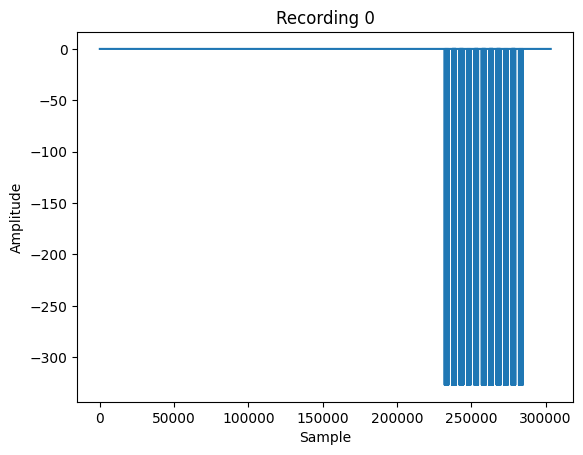

Recording 1 contains PHOTIC PH channel
Recording 1 contains PHOTIC PH data


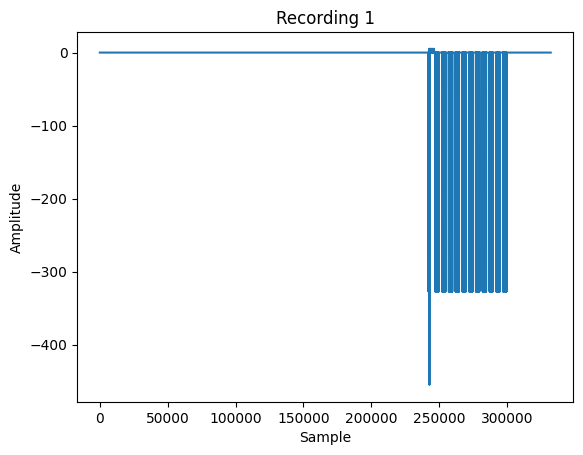

Recording 2 contains PHOTIC PH channel
Recording 2 contains PHOTIC PH data


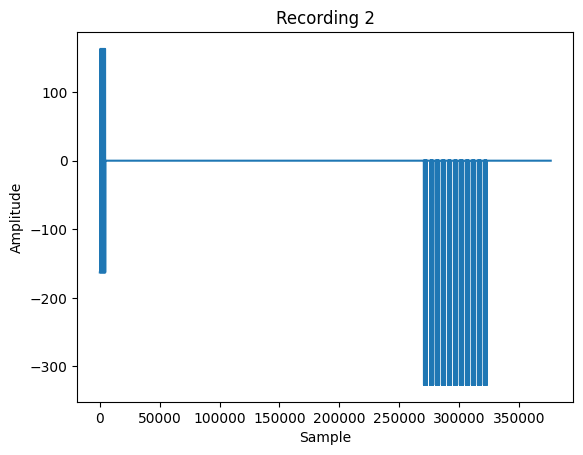

Recording 3 contains PHOTIC PH channel
Recording 3 contains PHOTIC PH data


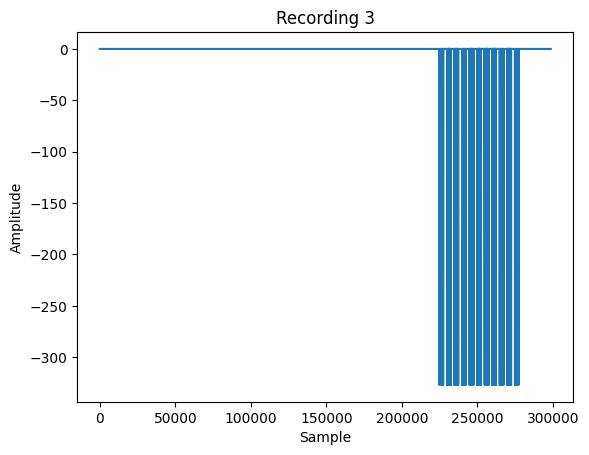

Recording 4 contains PHOTIC PH channel
Recording 4 contains PHOTIC PH data with zeros
Recording 5 contains PHOTIC PH channel
Recording 5 contains PHOTIC PH data


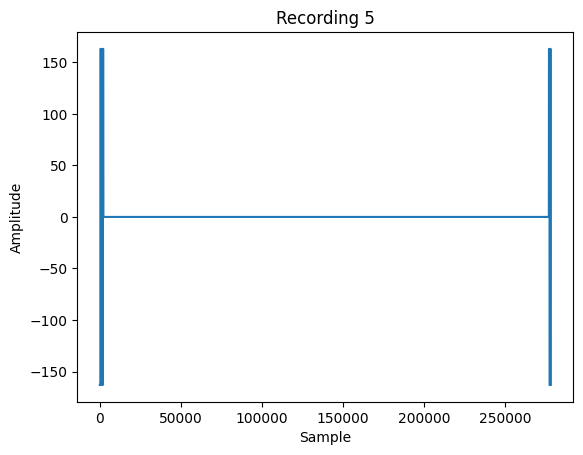

Recording 6 contains PHOTIC PH channel
Recording 6 contains PHOTIC PH data


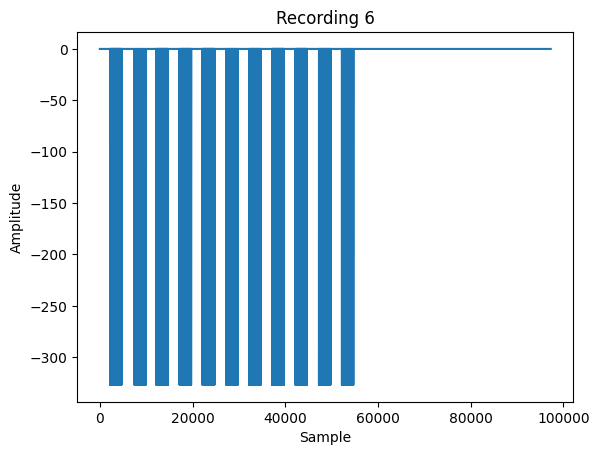

Recording 7 contains PHOTIC PH channel
Recording 7 contains PHOTIC PH data


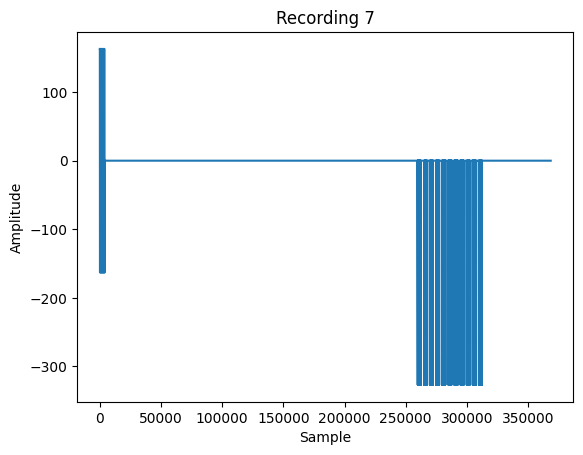

Recording 8 contains PHOTIC PH channel
Recording 8 contains PHOTIC PH data


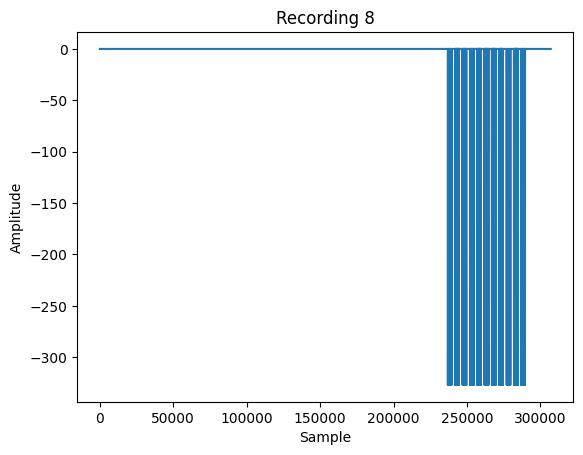

Recording 9 contains PHOTIC PH channel
Recording 9 contains PHOTIC PH data


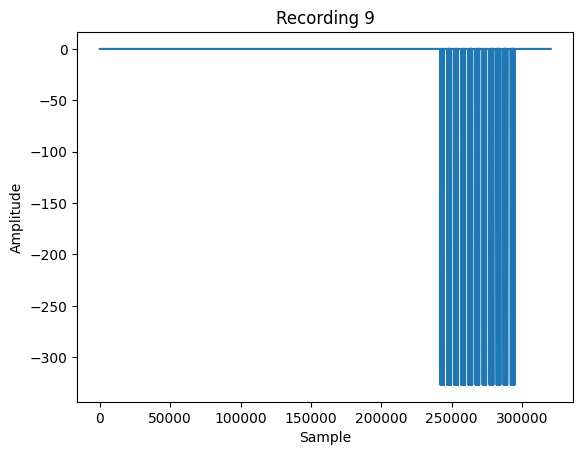

Recording 10 contains PHOTIC PH channel
Recording 10 contains PHOTIC PH data


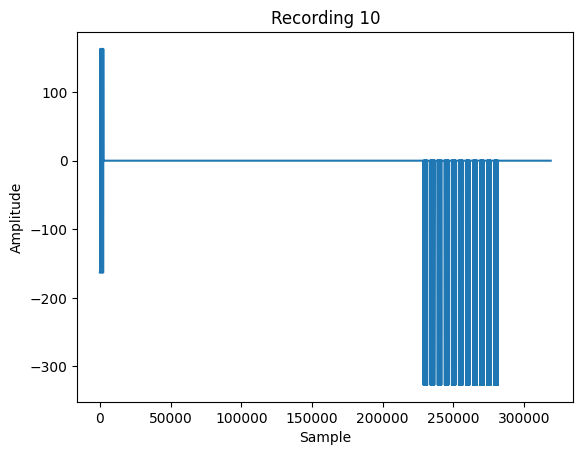

Recording 11 contains PHOTIC PH channel
Recording 11 contains PHOTIC PH data


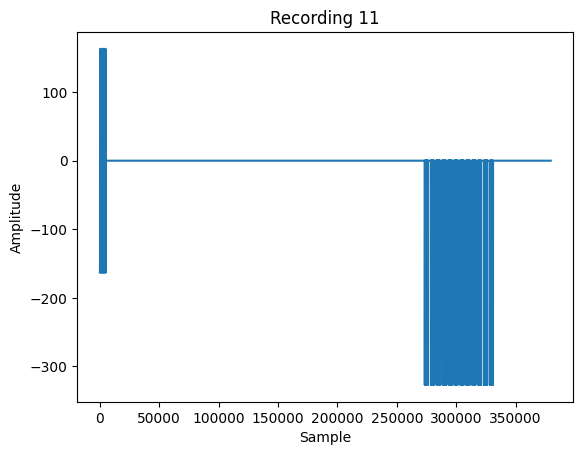

Recording 12 contains PHOTIC PH channel
Recording 12 contains PHOTIC PH data with zeros
Recording 13 contains PHOTIC PH channel
Recording 13 contains PHOTIC PH data with zeros
Recording 14 contains PHOTIC PH channel
Recording 14 contains PHOTIC PH data with zeros
Recording 15 contains PHOTIC PH channel
Recording 15 contains PHOTIC PH data with zeros
Recording 16 contains PHOTIC PH channel
Recording 16 contains PHOTIC PH data with zeros
Recording 17 contains PHOTIC PH channel
Recording 17 contains PHOTIC PH data with zeros
Recording 18 contains PHOTIC PH channel
Recording 18 contains PHOTIC PH data with zeros
Recording 19 contains PHOTIC PH channel
Recording 19 contains PHOTIC PH data with zeros


In [24]:
for i, set in enumerate(tuep.datasets[:20]):

    if 'PHOTIC PH' in set.raw.ch_names:
        print(f"Recording {i} contains PHOTIC PH channel")
        if np.any(set.raw.get_data(picks='PHOTIC PH')[0] != np.zeros(set.raw.get_data(picks='PHOTIC PH')[0].shape)):
            print(f"Recording {i} contains PHOTIC PH data")
            plt.figure()
            plt.title(f"Recording {i}")
            plt.plot(set.raw.get_data(picks='PHOTIC PH')[0])
            plt.xlabel('Sample')
            plt.ylabel('Amplitude')
            plt.show()

        elif np.any(set.raw.get_data(picks='PHOTIC PH')[0] == np.zeros(set.raw.get_data(picks='PHOTIC PH')[0].shape)):
            print(f"Recording {i} contains PHOTIC PH data with zeros")

In [35]:
for i in range(len(windows_tuep)):
    win=windows_tuep[i]

    idx , starttime, stoptime = win[2]

    if 'PHOTIC PH' in win.raw.ch_names:
        print(f"Recording {i} contains PHOTIC PH channel")
    if np.any(win.raw.get_data(picks='PHOTIC PH')[0] != np.zeros(win.raw.get_data(picks='PHOTIC PH')[0].shape)):
        print(f"Recording {i} contains PHOTIC PH data")
        plt.figure()
        plt.title(f"Recording {i}")
        plt.plot(win.raw.get_data(picks='PHOTIC PH')[0][starttime:stoptime])
        plt.xlabel('Sample')
        plt.ylabel('Amplitude')
        plt.show()

    elif np.any(win.raw.get_data(picks='PHOTIC PH')[0] == np.zeros(win.raw.get_data(picks='PHOTIC PH')[0].shape)):
        print(f"Recording {i} contains PHOTIC PH data with zeros")

(33, 2500)


AttributeError: 'tuple' object has no attribute 'raw'

## Dataloaders

In [58]:
from torch.utils.data import DataLoader

# Create a dataloader with the indexes found
dataloader = DataLoader(windows_tuep, batch_size=10, num_workers=4, drop_last=True)



In [59]:
print(len(dataloader))

for i, data in enumerate(dataloader):
    print(i, data[0].shape)
    if i == 10:
        break

2635
0 torch.Size([10, 33, 2500])
1 torch.Size([10, 33, 2500])
2 torch.Size([10, 33, 2500])
3 torch.Size([10, 33, 2500])
4 torch.Size([10, 33, 2500])
5 torch.Size([10, 33, 2500])
6 torch.Size([10, 33, 2500])
7 torch.Size([10, 33, 2500])
8 torch.Size([10, 33, 2500])
9 torch.Size([10, 33, 2500])
10 torch.Size([10, 33, 2500])


In [ ]:
def resample_data(ds, target_freq=250):
    for i in range(len(ds)):
        if ds[i].raw.info['sfreq'] != target_freq:
            print(f"Resampling recording {i} from {ds[i].raw.info['sfreq']} Hz to {target_freq} Hz")
            ds[i].raw.resample(target_freq,n_jobs=4)
        elif ds[i].raw.info['sfreq'] == target_freq:
            print(f"Recording {i} already at {target_freq} Hz")
    return ds

tuep.datasets[:200]=resample_data(tuep.datasets[:200], target_freq=250)